# Augmented Dataset: Rotation + Black Spots

Pipeline per image:
1. **Original**: YOLO crop then add black spots
2. **Rotated**: rotate raw image (-45 to +45 degrees) and rotate coordinates, then YOLO crop, then add black spots

This notebook visualises each step and then creates the full augmented dataset.

In [17]:
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wings.config import RAW_DATA_DIR, COUNTRIES, MODELS_DIR, COORDS_SUFX
from wings.detection.dataset import collect_image_paths
from wings.detection.augment_dataset import (
    rotate_image_and_coords,
    add_triangle_noise,
    apply_color_jitter,
    _read_row_coordinates,
    _pick_best_box,
    _clip_box,
)
from ultralytics import YOLO

yolo_model = YOLO(MODELS_DIR / 'yolo26n' / 'best.pt').to('cuda')

def draw_coords(img_bgr, x, y, color=(0, 255, 0), r=4):
    out = img_bgr.copy()
    for xi, yi in zip(x.astype(int), y.astype(int)):
        cv2.circle(out, (xi, yi), r, color, -1)
    return cv2.cvtColor(out, cv2.COLOR_BGR2RGB)

## 1. Load a sample raw image

2026-06-27 14:26:47.901 | INFO     | wings.detection.dataset:collect_image_paths:30 - Collecting image paths from: C:\Users\X\projects\bees\data\raw
C:\Users\X\projects\bees\data\raw\GR-wing-images\GR-0131-2005-TR-041-5.dw.png


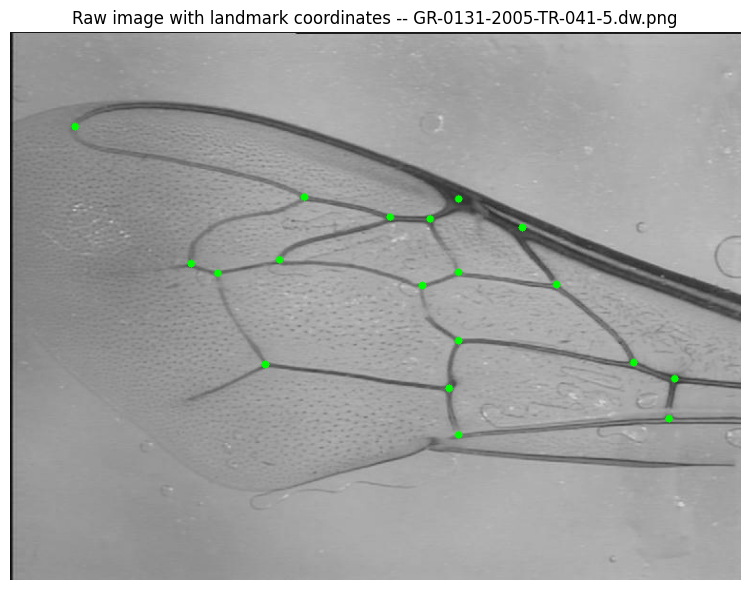

In [18]:
image_paths = collect_image_paths(RAW_DATA_DIR, COUNTRIES)
sample_path = random.choice(image_paths)
print(sample_path)

image = cv2.imread(str(sample_path), cv2.IMREAD_COLOR)

country = sample_path.name.split('-')[0]
df = pd.read_csv(RAW_DATA_DIR / f'{country}{COORDS_SUFX}')
row = df[df['file'] == sample_path.name].iloc[0]
x_coords, y_coords_top = _read_row_coordinates(row, image.shape[0])

plt.figure(figsize=(10, 6))
plt.imshow(draw_coords(image, x_coords, y_coords_top))
plt.title(f'Raw image with landmark coordinates -- {sample_path.name}')
plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Rotate image and coordinates

Rotation angle: -31.0 degrees


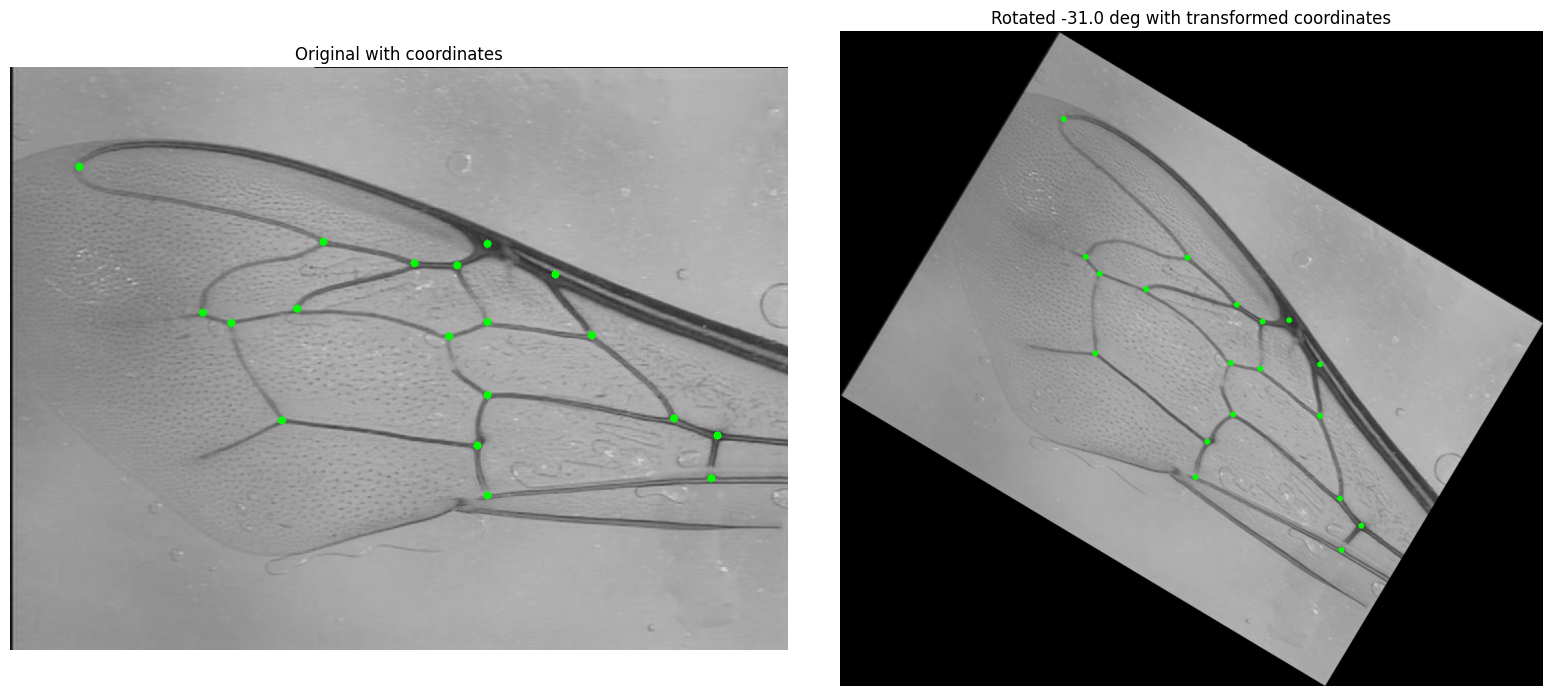

In [19]:
rng = np.random.default_rng(42)
sign = rng.choice([-1.0, 1.0])
angle = float(sign * rng.uniform(20, 45))
print(f"Rotation angle: {angle:.1f} degrees")

rot_image, rot_x, rot_y_top = rotate_image_and_coords(image, x_coords, y_coords_top, angle)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(draw_coords(image, x_coords, y_coords_top))
axes[0].set_title("Original with coordinates")
axes[0].axis("off")

axes[1].imshow(draw_coords(rot_image, rot_x, rot_y_top))
axes[1].set_title(f"Rotated {angle:.1f} deg with transformed coordinates")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 3. YOLO detection and crop on the rotated image

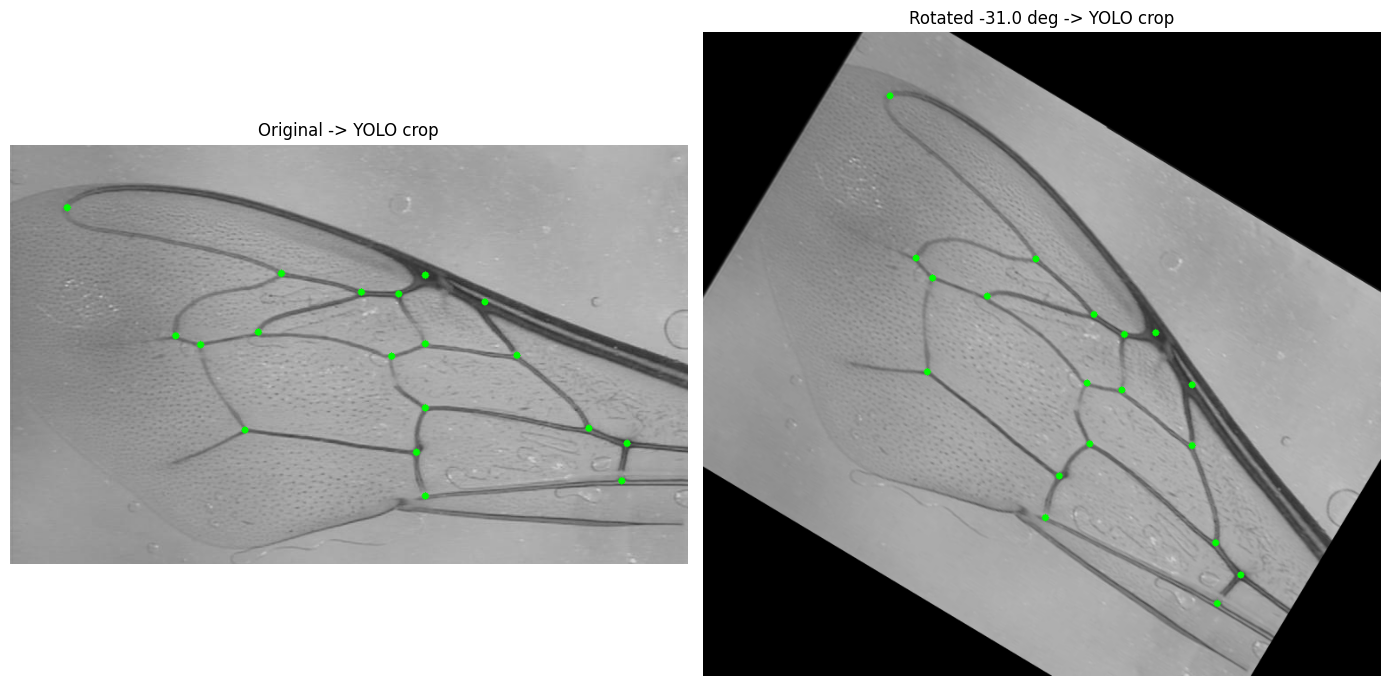

In [20]:
def yolo_crop_with_coords(img_bgr, x_top, y_top, model, conf=0.25):
    result = model.predict(img_bgr, conf=conf, verbose=False)[0]
    best_box = _pick_best_box(result)
    clipped = _clip_box(best_box, img_bgr.shape) if best_box else None
    if clipped is None:
        return img_bgr.copy(), x_top.copy(), y_top.copy()
    xmin, ymin, xmax, ymax = clipped
    crop = img_bgr[ymin:ymax, xmin:xmax]
    new_x = np.clip(x_top - xmin, 0, crop.shape[1] - 1)
    new_y = np.clip(y_top - ymin, 0, crop.shape[0] - 1)
    return crop, new_x, new_y


orig_crop, orig_cx, orig_cy = yolo_crop_with_coords(image,     x_coords, y_coords_top, yolo_model)
rot_crop,  rot_cx,  rot_cy  = yolo_crop_with_coords(rot_image, rot_x,    rot_y_top,    yolo_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(draw_coords(orig_crop, orig_cx, orig_cy))
axes[0].set_title('Original -> YOLO crop')
axes[0].axis('off')

axes[1].imshow(draw_coords(rot_crop, rot_cx, rot_cy))
axes[1].set_title(f'Rotated {angle:.1f} deg -> YOLO crop')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 4. Add augmentations (sparse triangle noise + brightness/contrast jitter)

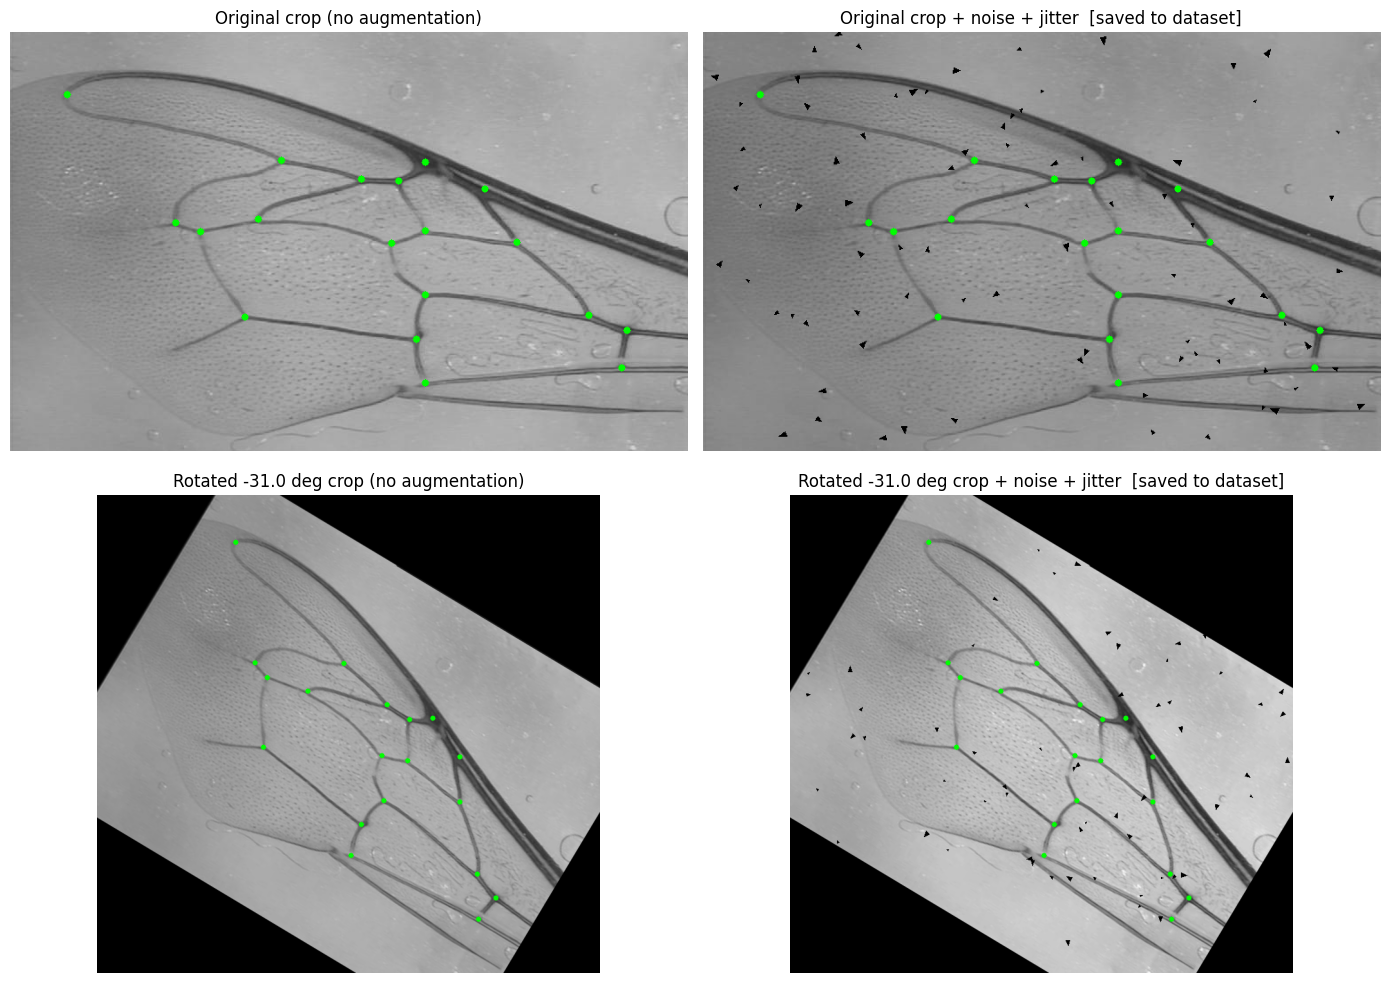

In [21]:
N_TRIANGLES, MIN_S, MAX_S = 80, 2, 6
BRIGHTNESS, CONTRAST = 0.3, 0.3

noisy_orig = apply_color_jitter(add_triangle_noise(orig_crop, n_triangles=N_TRIANGLES, min_size=MIN_S, max_size=MAX_S, rng=rng), brightness=BRIGHTNESS, contrast=CONTRAST, rng=rng)
noisy_rot  = apply_color_jitter(add_triangle_noise(rot_crop,  n_triangles=N_TRIANGLES, min_size=MIN_S, max_size=MAX_S, rng=rng), brightness=BRIGHTNESS, contrast=CONTRAST, rng=rng)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(draw_coords(orig_crop,  orig_cx, orig_cy))
axes[0, 0].set_title("Original crop (no augmentation)")
axes[0, 0].axis("off")

axes[0, 1].imshow(draw_coords(noisy_orig, orig_cx, orig_cy))
axes[0, 1].set_title("Original crop + noise + jitter  [saved to dataset]")
axes[0, 1].axis("off")

axes[1, 0].imshow(draw_coords(rot_crop,  rot_cx, rot_cy))
axes[1, 0].set_title(f"Rotated {angle:.1f} deg crop (no augmentation)")
axes[1, 0].axis("off")

axes[1, 1].imshow(draw_coords(noisy_rot, rot_cx, rot_cy))
axes[1, 1].set_title(f"Rotated {angle:.1f} deg crop + noise + jitter  [saved to dataset]")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## 5. Final model input (padded to 400x400)

Apply `unet_fit_rectangle_preprocess` and map coordinates into the padded space.
This is exactly what the UNet receives during training.

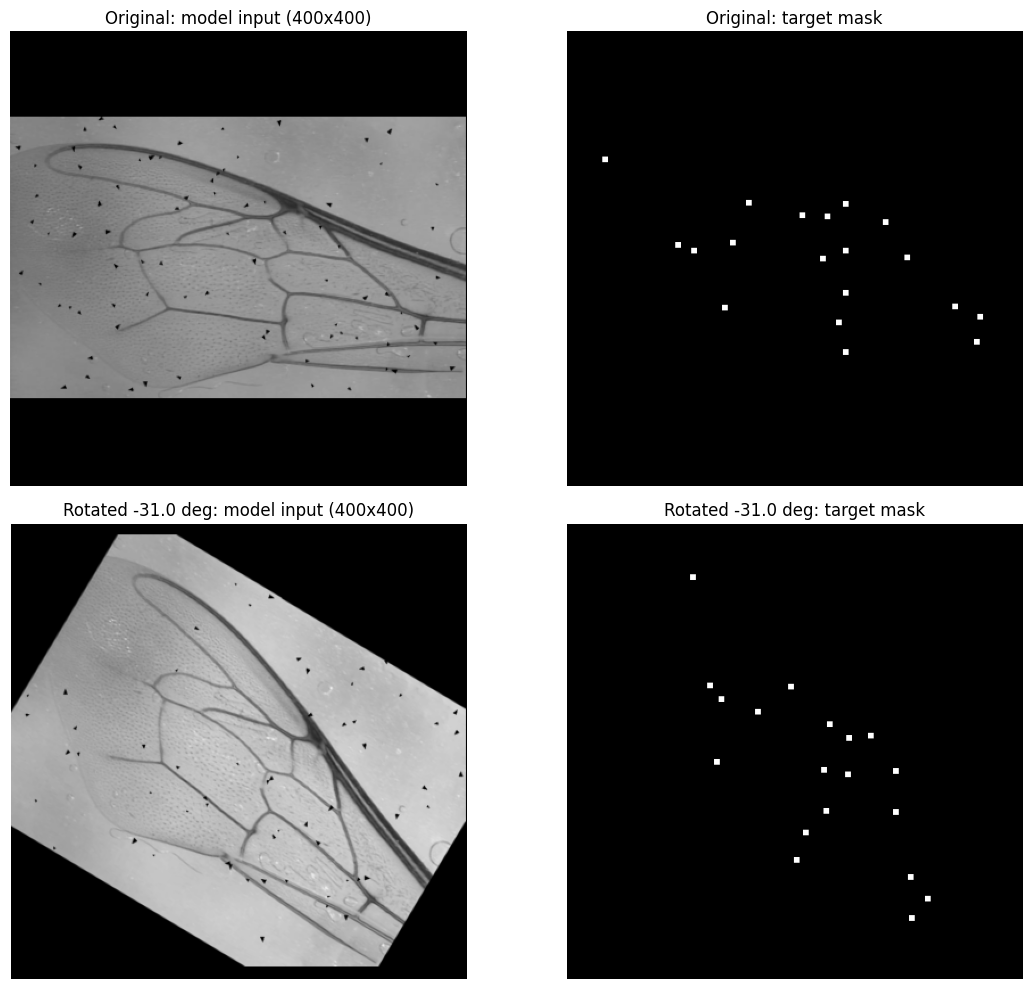

In [22]:
import torch
import torchvision.transforms.functional as TF
from wings.visualizing.image_preprocess import unet_fit_rectangle_preprocess, unet_reverse_padding

OUTPUT_SIZE = 400
SQUARE_SIZE = 5  # same as used during training

def to_model_input_and_mask(img_bgr, x_top, y_top, output_size=OUTPUT_SIZE, square_size=SQUARE_SIZE):
    orig_h, orig_w = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).contiguous()

    preprocessed, _, _ = unet_fit_rectangle_preprocess(img_tensor, output_size=output_size)

    pad_left, pad_top, pad_right, pad_bottom = unet_reverse_padding(
        preprocessed[0], orig_w, orig_h
    )
    scale = (output_size - 1) / max(orig_w, orig_h)

    new_x   = (x_top * scale + pad_left).astype(int)
    new_y   = (y_top * scale + pad_top).astype(int)  # top-left convention

    # Target mask: small squares at each landmark (top-left indexing)
    half = square_size // 2
    mask = np.zeros((output_size, output_size), dtype=np.float32)
    for x, y in zip(new_x, new_y):
        mask[max(0, y-half):min(output_size, y+half+1),
             max(0, x-half):min(output_size, x+half+1)] = 1.0

    # Display image: same resize+pad without normalisation
    vis = TF.resize(img_tensor, output_size - 1,
                    interpolation=TF.InterpolationMode.BILINEAR,
                    antialias=True, max_size=output_size)
    vis = TF.pad(vis, [pad_left, pad_top, pad_right, pad_bottom])
    vis_np = vis.permute(1, 2, 0).numpy()

    return vis_np, mask


orig_vis, orig_mask = to_model_input_and_mask(noisy_orig, orig_cx, orig_cy)
rot_vis,  rot_mask  = to_model_input_and_mask(noisy_rot,  rot_cx,  rot_cy)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(orig_vis)
axes[0, 0].set_title(f"Original: model input ({OUTPUT_SIZE}x{OUTPUT_SIZE})")
axes[0, 0].axis("off")

axes[0, 1].imshow(orig_mask, cmap="gray")
axes[0, 1].set_title("Original: target mask")
axes[0, 1].axis("off")

axes[1, 0].imshow(rot_vis)
axes[1, 0].set_title(f"Rotated {angle:.1f} deg: model input ({OUTPUT_SIZE}x{OUTPUT_SIZE})")
axes[1, 0].axis("off")

axes[1, 1].imshow(rot_mask, cmap="gray")
axes[1, 1].set_title(f"Rotated {angle:.1f} deg: target mask")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## 6. Sanity check -- coordinate consistency across angles

Verifies that the rotation matrix is applied correctly at several angles.

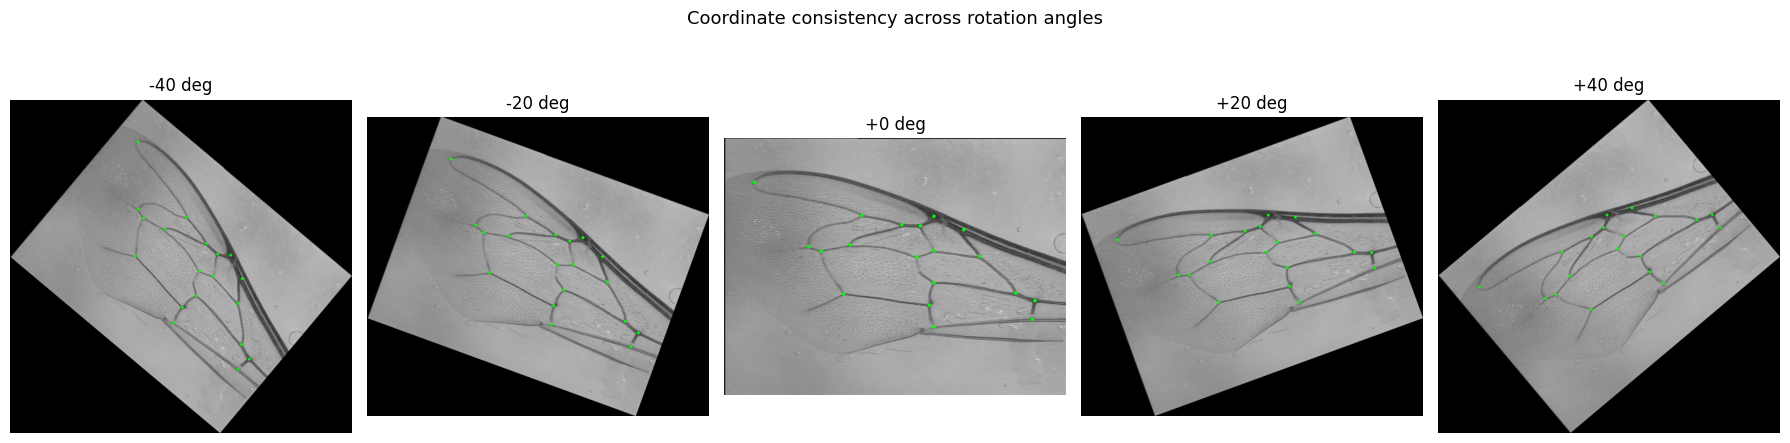

In [23]:
angles = [-40, -20, 0, 20, 40]

fig, axes = plt.subplots(1, len(angles), figsize=(18, 5))
for ax, a in zip(axes, angles):
    r_img, r_x, r_y = rotate_image_and_coords(image, x_coords, y_coords_top, a)
    ax.imshow(draw_coords(r_img, r_x, r_y))
    ax.set_title(f'{a:+d} deg')
    ax.axis('off')

plt.suptitle('Coordinate consistency across rotation angles', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Create the full augmented dataset

Runs the complete pipeline for all countries.  
Output: `data/processed/cropped-augmented/`  
Each country folder contains an image directory and an updated CSV.  
Expected output: ~2x the original dataset size.

In [24]:
# from wings.detection.augment_dataset import create_augmented_dataset
# from wings.config import PROCESSED_DATA_DIR, MODELS_DIR

# stats = create_augmented_dataset(
#     yolo_model_path=MODELS_DIR / "yolo26n" / "best.pt",
#     output_folder=PROCESSED_DATA_DIR / "cropped-augmented2",
#     min_angle=20.0,
#     max_angle=45.0,
#     n_triangles=40,
#     min_size=3,
#     max_size=9,
#     brightness=0.3,
#     contrast=0.3,
#     seed=42,
# )

# print(stats)

2026-06-27 14:26:50.776 | INFO     | wings.detection.augment_dataset:create_augmented_dataset:366 - Processing country: AT


AT: 100%|██████████| 198/198 [00:13<00:00, 14.41img/s]


2026-06-27 14:27:04.530 | INFO     | wings.detection.augment_dataset:process_country_augmented:335 - Wrote 396 records to C:\Users\X\projects\bees\data\processed\cropped-augmented\AT-raw-coordinates.csv
2026-06-27 14:27:04.530 | INFO     | wings.detection.augment_dataset:create_augmented_dataset:366 - Processing country: GR


GR: 100%|██████████| 1444/1444 [02:09<00:00, 11.13img/s]


2026-06-27 14:29:14.274 | INFO     | wings.detection.augment_dataset:process_country_augmented:335 - Wrote 2888 records to C:\Users\X\projects\bees\data\processed\cropped-augmented\GR-raw-coordinates.csv
2026-06-27 14:29:14.275 | INFO     | wings.detection.augment_dataset:create_augmented_dataset:366 - Processing country: HR


...

2026-06-27 14:43:48.737 | INFO     | wings.detection.augment_dataset:process_country_augmented:335 - Wrote 11910 records to C:\Users\X\projects\bees\data\processed\cropped-augmented\PL-raw-coordinates.csv
2026-06-27 14:43:48.737 | INFO     | wings.detection.augment_dataset:create_augmented_dataset:366 - Processing country: RO


RO: 100%|██████████| 6498/6498 [07:51<00:00, 13.78img/s]


2026-06-27 14:51:40.593 | INFO     | wings.detection.augment_dataset:process_country_augmented:335 - Wrote 12996 records to C:\Users\X\projects\bees\data\processed\cropped-augmented\RO-raw-coordinates.csv
2026-06-27 14:51:40.598 | INFO     | wings.detection.augment_dataset:create_augmented_dataset:366 - Processing country: SI


SI: 100%|██████████| 835/835 [00:59<00:00, 13.97img/s]

2026-06-27 14:52:40.581 | INFO     | wings.detection.augment_dataset:process_country_augmented:335 - Wrote 1670 records to C:\Users\X\projects\bees\data\processed\cropped-augmented\SI-raw-coordinates.csv
2026-06-27 14:52:40.581 | INFO     | wings.detection.augment_dataset:create_augmented_dataset:386 - Done. Output: C:\Users\X\projects\bees\data\processed\cropped-augmented
2026-06-27 14:52:40.581 | INFO     | wings.detection.augment_dataset:create_augmented_dataset:387 - Summary: {'total': 21722, 'original': 21722, 'rotated': 21722, 'skipped': 0}
{'total': 21722, 'original': 21722, 'rotated': 21722, 'skipped': 0}
